In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
import os
import OptimalBattery.global_config as gcf
import OptimalBattery.util as ut



In [2]:
data_path = gcf.data_path

# build transition matrix for visualization only...

In [3]:
dat_file = df = pd.read_csv(f"{data_path}/Cerebellum/super_cerebellum/sc1/data/s16/sc1_s16.dat", delim_whitespace=True, header=0)
filtered_dat = dat_file[dat_file["runNum"] >= 51]

# Cerebellum

In [23]:
# define atlas and dirs
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)
func_fus_dir = os.path.join(data_path, 'FunctionalFusion_new')

MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')
subj = None
data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='TaskRun',subj=subj)
# nans to 0
data_mdtb_s1_run = np.nan_to_num(data_mdtb_s1_run)
n_sub, n_reg,n_vox = data_mdtb_s1_run.shape

# needed to map runs from the old(data files) to the new(info_mdtb_1_run)
run_map = {51: 1,52: 2,53: 3,54: 4,55: 5,56: 6,57: 7,58: 8,59: 9,60: 10,61: 11,62: 12,63: 13,64: 14,65: 15,66: 16,}


cond_vec = info_mdtb_1_run['task_num'].values
part_vec  = info_mdtb_1_run["run"].values

# Remove task mean from each task condition for all runs
data_residual = data_mdtb_s1_run.copy()
for t in np.unique(cond_vec):
    mask = (cond_vec == t)
    task_mean = data_mdtb_s1_run[:, mask, :].mean(axis=1, keepdims=True)
    data_residual[:, mask, :] = data_mdtb_s1_run[:, mask, :] - task_mean
    

In [24]:
data_residual_reordered, info_mdtb_1_run_reordered = ut.reorder_mdtb(
    data_residual,
    info_mdtb_1_run,
    filtered_dat,
    run_map= run_map
)

unique_task_numbers = info_mdtb_1_run_reordered['task_num_orig'].unique()
n_tasks = len(unique_task_numbers)
data_task_positions = np.zeros((n_sub, len(unique_task_numbers),n_vox))

for i, task_number in enumerate(unique_task_numbers):
    mask = info_mdtb_1_run_reordered['task_num_orig'] == task_number
    data_task_positions[:, i, :] = np.mean(data_residual[:, mask, :], axis=1)



In [25]:
cov_mats = np.zeros((n_sub, n_tasks, n_tasks))
for s in range(n_sub):
    X = data_task_positions[s, :, :] 
    cov_mats[s] = np.cov(X, rowvar=True)


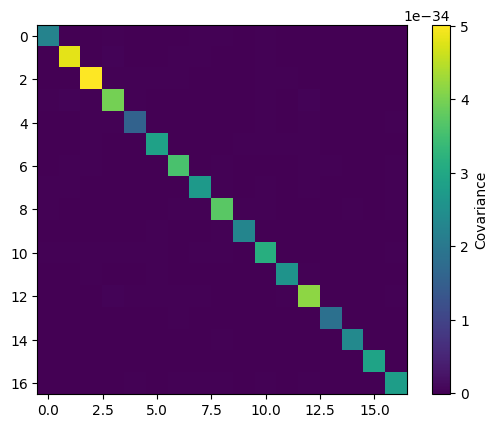

In [26]:
# average covariance matrix across subjects
mean_cov_mat = np.mean(cov_mats, axis=0)

plt.imshow(mean_cov_mat, cmap='viridis')
plt.colorbar(label='Covariance')

In [ ]:
n_tasks = mean_cov_mat.shape[0]

# collect by lag
lags = np.arange(1, n_tasks)   # 1..16
mean_by_lag = []

for lag in lags:
    vals = []
    for i in range(n_tasks - lag):
        vals.append(mean_cov_mat[i, i+lag])
    mean_by_lag.append(np.mean(vals))

mean_by_lag = np.array(mean_by_lag)



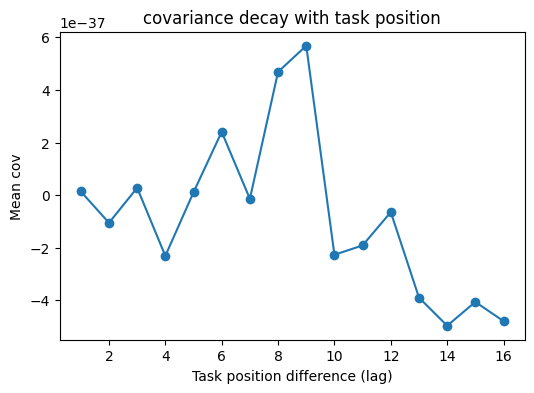

In [36]:
plt.figure(figsize=(6,4))
plt.plot(lags, mean_by_lag, marker='o')
plt.xlabel("Task position difference (lag)")
plt.ylabel("Mean cov")
plt.title("covariance decay with task position")
plt.show()
